
Metadata Info:
  columns: ['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]']
  missing_values: {'Image Index': 0, 'Finding Labels': 0, 'Follow-up #': 0, 'Patient ID': 0, 'Patient Age': 0, 'Patient Gender': 0, 'View Position': 0, 'OriginalImage[Width': 0, 'Height]': 0, 'OriginalImagePixelSpacing[x': 0, 'y]': 0}
  total_entries: 112120

File Stats:
  total_metadata_images: 112120
  total_folder_images: 34999
  missing_images: 77121
  extra_images: 0

Disease Counts:
  Cardiomegaly: 2776
  Emphysema: 2516
  Effusion: 13317
  No Finding: 60361
  Hernia: 227
  Infiltration: 19894
  Mass: 5782
  Nodule: 6331
  Atelectasis: 11559
  Pneumothorax: 5302
  Pleural_Thickening: 3385
  Pneumonia: 1431
  Fibrosis: 1686
  Edema: 2303
  Consolidation: 4667


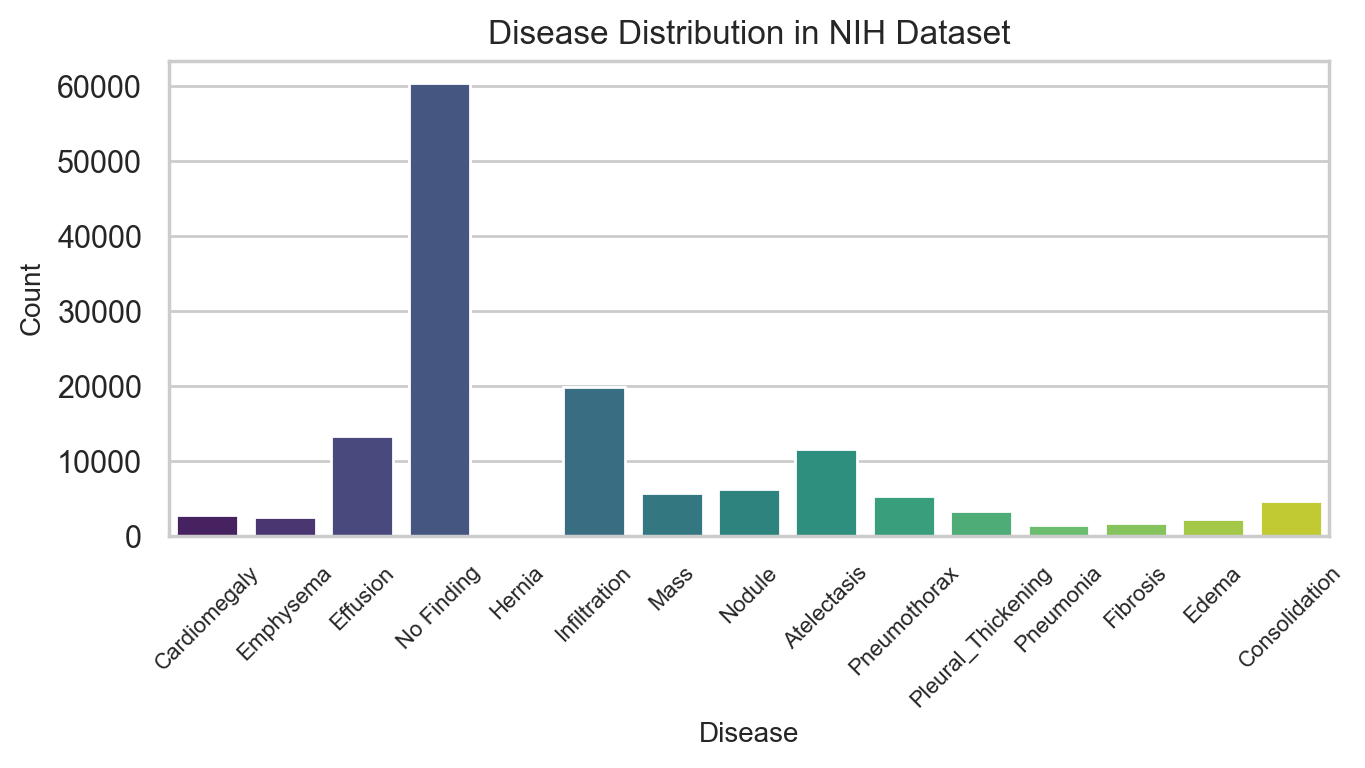

In [ ]:
# Enable autoreload
%load_ext autoreload
%autoreload 2

import config as cfg

from src.utils.DatasetTools import analyze_nih_dataset
import matplotlib.pyplot as plt


stats = analyze_nih_dataset()

# Print statistics in a more readable format
print("\nMetadata Info:")
for key, value in stats['metadata_info'].items():
    print(f"  {key}: {value}")

print("\nFile Stats:")
for key, value in stats['file_stats'].items():
    print(f"  {key}: {value}")

print("\nDisease Counts:")
for disease, count in stats['disease_counts'].items():
    print(f"  {disease}: {count}")

# Display the plot
plt.show()



In [1]:
%reload_ext autoreload

from src.utils.DatasetTools import preprocess_and_split_csv
from rich import print

stats = preprocess_and_split_csv()
print(stats)

{
    'train_size': 11824,
    'validate_size': 1353,
    'test_size': 1416,
    'total_size': 14593,
    'train_csv_path': 'C:\\Users\\maksi\\Desktop\\master\\InfernoCalibNet\\data\\refined\\train.csv',
    'validate_csv_path': 'C:\\Users\\maksi\\Desktop\\master\\InfernoCalibNet\\data\\refined\\validate.csv',
    'test_csv_path': 'C:\\Users\\maksi\\Desktop\\master\\InfernoCalibNet\\data\\refined\\test.csv'
}

In [ ]:
from src.XrayDataset import XrayDataset
from torch.utils.data import DataLoader
from rich import print

from config import BATCH_SZ, NUM_WRKRS

train_dataset = XrayDataset(split="train", augmentations=True)
validate_dataset = XrayDataset(split="validate", augmentations=False)
test_dataset = XrayDataset(split="test", augmentations=False)


# Access the first row of the dataset
image, label = test_dataset[0]

# Print the contents
print("Image Tensor Shape:", image.shape)
print("Label Tensor:", label)

# Create DataLoader objects
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SZ, shuffle=True, num_workers=NUM_WRKRS
)
val_loader = DataLoader(
    validate_dataset, batch_size=BATCH_SZ, shuffle=False, num_workers=NUM_WRKRS
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SZ, shuffle=False, num_workers=NUM_WRKRS
)

for images, labels in train_loader:
    # images: Tensor of shape (batch_size, channels, height, width)
    # labels: Tensor of shape (batch_size, num_classes)
    print("Batch Images Shape:", images.shape)
    print("Batch Labels Shape:", labels.shape)
    break 

Image Tensor Shape:
torch.Size([1, 224, 224])

Label Tensor: tensor([0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.])

Batch Images Shape:
torch.Size([32, 1, 224, 224])

Batch Labels Shape:
torch.Size([32, 13])

In [ ]:
import torch
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.nn import BCEWithLogitsLoss
from src.NNModels import XrayResNet
from src.ICNTrainer import ICNTrainer
from config import LR

model = XrayResNet()
criterion = BCEWithLogitsLoss()
optimizer = Adam(model.parameters(), lr=LR)
scheduler = ReduceLROnPlateau(optimizer, mode="min", patience=3, factor=0.1)
loaders = {"train": train_loader, "val": val_loader}

trainer = ICNTrainer(
    device=torch.device("cuda"),
    model=model,
    loaders=loaders,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
)
trainer.fit()